# Nike distribution case study: Direct, wholesale, and challenger growth

**Research window: January 1, 2019 through September 15, 2026.**

This notebook studies a specific investment question: did Nike's shift toward its Direct
channel coincide with weaker wholesale relationships and faster challenger growth, and what
evidence would be needed to say Nike's strategy *caused* that growth?

The notebook is descriptive. It calculates channel mix, growth, indexed revenue, retailer
concentration and simple correlations. It does not estimate Nike's global running-shoe market
share, assign competitor revenue to Nike, or change the DCF. Read each Markdown cell before
its code: every step gives the operation, why it matters, and any important assumption.

The most important definition is also the easiest to misuse:

- **Nike Direct** includes Nike-owned digital commerce **and physical stores**.
- **Wholesale** means sales to retail partners, which may sell through **stores and websites**.

The filings therefore support a company-operated-versus-partner distribution analysis. They
do not provide a clean online-versus-offline split.

## Sources and boundaries

The three operating datasets were built from annual SEC reports already converted to Markdown
with `sec2md`. The preprocessing workflow preserves the original filing URL and Markdown line
for each value. A fourth prepared dataset contains Yahoo Finance adjusted closes. Every prepared
file is recorded in `preprocessing_manifest.csv`.

| Dataset | Scope | Key limitation |
|---|---|---|
| `nike_channel_history.csv` | Nike wholesale and Direct revenue, FY2019-FY2026; Nike Inc. gross margin | Direct combines owned stores and digital; gross margin covers all Nike Inc. |
| `peer_channel_history.csv` | Deckers filing-derived channel series in USD; On consolidated channels in CHF | Different currencies, fiscal calendars, product scopes and company maturity |
| `foot_locker_nike_concentration.csv` | Foot Locker purchases from Nike, 2019-2024 | Vendor purchases are not Nike sales, footwear share, sell-through or running-specialty share |
| `equity_price_history.csv` | Daily adjusted closes for NKE, DECK and ONON | On begins at its September 2021 listing; co-movement around events is not causal evidence |

Primary source: [SEC EDGAR](https://www.sec.gov/search-filings). Preprocessing notebook:
`data_extraction/preprocess_all.ipynb`. Supporting research and non-SEC sources:
`research/nike_running_distribution_case_study.md`. Daily adjusted closes come from the
[Yahoo Finance chart API](https://query2.finance.yahoo.com/v8/finance/chart/NKE); the prepared
price table preserves the corresponding ticker endpoint on every row.

The Consumer Direct Acceleration strategy was announced in 2020, emphasizing digital,
owned stores and selected strategic partners. The company sources are linked in the project
README and research memo. Strategy timing is context, not a randomized treatment date.

> **ASSUMPTION:** `Deckers` is the consistent display label for the Deckers filing-derived
> channel series. The series should not be interpreted as consolidated Deckers revenue.


## How to reason about the evidence

An equity-research case study should keep four levels separate:

1. **Observation:** a reported number changed.
2. **Mechanism:** a plausible business process connects the changes.
3. **Alternative explanation:** another process could create the same pattern.
4. **Causality:** a research design isolates the mechanism from alternatives.

Here, increasing Nike Direct mix and falling Foot Locker vendor concentration are observations.
Reduced shelf visibility and staff recommendations are a plausible mechanism. Rival product
innovation, COVID closures, category growth, supply constraints and Foot Locker's own choices
are alternative explanations. The public annual data do not isolate causality.

## Step 1: Load the analysis tools

**Formula or operation:** Import table and plotting libraries.

**Why?** The notebook uses transparent dataframe operations and standard charts so every transformation can be inspected.

In [124]:
from pathlib import Path
import importlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import to_rgb
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from IPython.display import display


## Step 2: Set the project paths and visual system

**Formula or operation:** Locate the repository root, import the shared palette from
`ui/constants.py`, validate the logo files, and define reusable dark-chart helpers.

**Why?** Centralized colors keep every chart consistent. The supplied company logos make the
series easier to identify, while helper functions keep each logo at one fixed display size and
prevent charts from silently reverting to a white background or low-contrast labels.

> **ASSUMPTION:** Logos are recolored to their high-contrast series color for accessibility on
> a black background. Their geometry is unchanged, and logos appear only as part of labels.


In [125]:
root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'data/preprocess/preprocessing_manifest.csv').exists())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import importlib
import ui.constants as chart_constants
importlib.reload(chart_constants)
from ui.constants import (BACKGROUND, PANEL_BACKGROUND, TEXT, MUTED_TEXT, GRID,
                          REFERENCE, FOOT_LOCKER, COMPANY_COLORS, CHANNEL_COLORS,
                          LOGO_FILES, LOGO_DISPLAY_PX, EVENT_COLORS)

preprocess_root = root / 'data/preprocess'
case_data = preprocess_root / 'case_study'
logo_dir = root / 'data/logo'
output = root / 'data/results/distribution_case_study_learning'
research_start = pd.Timestamp('2019-01-01')
research_cutoff = pd.Timestamp('2026-09-15')

for company, filename in LOGO_FILES.items():
    assert (logo_dir / filename).exists(), f'Missing {company} logo: {filename}'

plt.rcParams.update({
    'figure.facecolor': BACKGROUND,
    'savefig.facecolor': BACKGROUND,
    'axes.facecolor': PANEL_BACKGROUND,
    'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,
    'xtick.color': MUTED_TEXT,
    'ytick.color': MUTED_TEXT,
    'text.color': TEXT,
    'legend.labelcolor': TEXT,
    'font.size': 10,
    'axes.titleweight': 'bold',
})


def style_axes(ax):
    ax.set_facecolor(PANEL_BACKGROUND)
    ax.grid(axis='y', color=GRID, linewidth=.8, alpha=.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED_TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)


def tinted_logo(company):
    image = plt.imread(logo_dir / LOGO_FILES[company])
    if image.shape[-1] == 3:
        alpha = np.ones(image.shape[:2], dtype=float)
    else:
        alpha = image[..., 3]
    visible = np.argwhere(alpha > .02)
    y0, x0 = visible.min(axis=0)
    y1, x1 = visible.max(axis=0) + 1
    alpha = alpha[y0:y1, x0:x1]
    stride = max(1, int(np.ceil(max(alpha.shape) / 160)))
    alpha = alpha[::stride, ::stride]
    tinted = np.zeros((*alpha.shape, 4), dtype=float)
    tinted[..., :3] = to_rgb(COMPANY_COLORS[company])
    tinted[..., 3] = alpha
    return tinted


def add_company_labels(ax, companies, y=.94, fontsize=9):
    x_positions = np.linspace(.02, .48, len(companies))
    for x, company in zip(x_positions, companies):
        add_logo_label(ax, company, x=x, y=y, fontsize=fontsize)


## Step 3: Load the manifest and four prepared datasets

**Formula or operation:** Confirm that the preprocessing manifest contains each case-study file,
then read the Nike, peer, Foot Locker and daily equity-price CSVs.

**Why?** The manifest check aligns this notebook with the current preprocessing workflow and
fails early if an input was renamed, omitted or moved.


In [126]:
preprocessing_manifest = pd.read_csv(preprocess_root / 'preprocessing_manifest.csv')
required_inputs = {
    'data/preprocess/case_study/nike_channel_history.csv',
    'data/preprocess/case_study/peer_channel_history.csv',
    'data/preprocess/case_study/foot_locker_nike_concentration.csv',
    'data/preprocess/case_study/equity_price_history.csv',
}
assert required_inputs.issubset(set(preprocessing_manifest.file))

nike = pd.read_csv(case_data / 'nike_channel_history.csv')
peers = pd.read_csv(case_data / 'peer_channel_history.csv')
foot_locker = pd.read_csv(case_data / 'foot_locker_nike_concentration.csv')
prices = pd.read_csv(case_data / 'equity_price_history.csv')
nike['fiscal_year_end'] = pd.to_datetime(nike.fiscal_year_end)
peers['fiscal_year_end'] = pd.to_datetime(peers.fiscal_year_end)
prices['date'] = pd.to_datetime(prices.date)

# Normalize presentation labels without changing the filing-derived values.
peers.loc[peers.company.str.contains('Deckers', case=False), 'company'] = 'Deckers'
peers.loc[peers.company.eq('On Holding'), 'company'] = 'On'
peers.loc[peers.company.eq('Deckers'), 'scope'] = 'Deckers reported channel series'

display(pd.Series({'nike_rows': len(nike), 'peer_rows': len(peers),
                   'foot_locker_rows': len(foot_locker),
                   'price_rows': len(prices),
                   'manifest_rows': len(preprocessing_manifest)}))


nike_rows              8
peer_rows             13
foot_locker_rows       6
price_rows          5127
manifest_rows         15
dtype: int64

## Step 4: Validate dates and unique observations

**Formula or operation:** Require one observation per company and fiscal year within the research window.

**Why?** Duplicates or dates outside the intended window would make growth calculations and comparisons ambiguous.

In [127]:
assert nike.fiscal_year.is_unique
assert not peers.duplicated(['company', 'fiscal_year']).any()
assert foot_locker.purchase_year.is_unique
assert not prices.duplicated(['ticker', 'date']).any()
assert nike.fiscal_year_end.between(research_start, research_cutoff).all()
assert peers.fiscal_year_end.between(research_start, research_cutoff).all()
assert foot_locker.purchase_year.between(2019, 2026).all()
assert prices.date.between(research_start, research_cutoff).all()
assert set(prices.company) == {'Nike', 'Deckers', 'On'}
assert prices.adj_close.gt(0).all()


## Step 5: Validate provenance

**Formula or operation:** Every observation must retain an SEC archive URL and a Markdown line.

**Why?** Traceability lets another analyst verify the reported value in the converted filing rather than trusting a chart alone.

In [128]:
for frame in [nike, peers, foot_locker]:
    assert frame.source_url.str.startswith('https://www.sec.gov/Archives/').all()
assert prices.source_url.str.startswith(
    'https://query2.finance.yahoo.com/v8/finance/chart/').all()
assert nike[['wholesale_md_line', 'direct_md_line', 'gross_margin_md_line']].notna().all().all()
assert peers[['wholesale_md_line', 'direct_md_line']].notna().all().all()
assert foot_locker.md_line.notna().all()


## Step 6: Validate units and economic identities

**Formula or operation:** Nike: wholesale + Direct + Global Brand Divisions = total; peers: wholesale + Direct = total.

**Why?** The Nike table excludes small Global Brand Divisions from its two-channel denominator, while peer totals contain only the two reported channels. This difference must stay explicit.

In [129]:
assert nike.currency.eq('USD').all() and nike.unit.eq('millions').all()
assert peers.unit.eq('millions').all()
assert (peers.loc[peers.company.eq('Deckers'), 'currency'] == 'USD').all()
assert (peers.loc[peers.company.eq('On'), 'currency'] == 'CHF').all()
assert np.allclose(peers.wholesale_revenue + peers.direct_revenue, peers.total_revenue,
                   atol=.11)
nike['global_brand_divisions'] = (nike.nike_brand_total - nike.nike_brand_wholesale
                                  - nike.nike_brand_direct)
assert nike.global_brand_divisions.ge(0).all()
display(nike[['fiscal_year', 'global_brand_divisions']])


,fiscal_year,global_brand_divisions
0,2019,42.0
1,2020,30.0
2,2021,25.0
3,2022,102.0
4,2023,58.0
5,2024,45.0
6,2025,48.0
7,2026,49.0


## Part 1: Nike's channel shift

First examine Nike on its own. This separates a change in channel **mix** from a change in
channel **dollars**. A channel can lose share of company revenue while its absolute revenue
still rises, and the reverse can also happen.

## Step 7: Recalculate Nike Direct share

**Formula or operation:** Direct share = Direct / (Direct + wholesale) x 100.

**Why?** This measures how much of the two major NIKE Brand channels is company-operated. It deliberately excludes Global Brand Divisions from the denominator.

> **ASSUMPTION:** This is a channel-ownership share, not an online-sales share. Nike-owned physical stores are included in Direct.

In [130]:
nike['direct_share_recalculated'] = 100 * nike.nike_brand_direct / (
    nike.nike_brand_direct + nike.nike_brand_wholesale)
assert np.allclose(nike.direct_share_recalculated,
                   nike.direct_share_of_wholesale_plus_direct_pct, atol=.01)
display(nike[['fiscal_year', 'nike_brand_direct', 'nike_brand_wholesale',
              'direct_share_recalculated']])

,fiscal_year,nike_brand_direct,nike_brand_wholesale,direct_share_recalculated
0,2019,11753.0,25423.0,31.614482
1,2020,12382.0,23156.0,34.841578
2,2021,16370.0,25898.0,38.729062
3,2022,18726.0,25608.0,42.238463
4,2023,21308.0,27397.0,43.749102
5,2024,21519.0,27758.0,43.669460
6,2025,18783.0,25883.0,42.052120
7,2026,17720.0,27453.0,39.226972


## Step 8: Calculate Nike channel growth

**Formula or operation:** Year-over-year growth = current channel revenue / prior channel revenue - 1.

**Why?** Growth rates reveal when Direct or wholesale expanded or contracted. The first observation has no prior year and remains missing.

In [131]:
nike['wholesale_yoy_growth'] = nike.nike_brand_wholesale.pct_change(fill_method=None)
nike['direct_yoy_growth'] = nike.nike_brand_direct.pct_change(fill_method=None)
display(nike[['fiscal_year', 'wholesale_yoy_growth', 'direct_yoy_growth']])

,fiscal_year,wholesale_yoy_growth,direct_yoy_growth
0,2019,NaN,NaN
1,2020,-0.089171,0.053518
2,2021,0.118414,0.322080
3,2022,-0.011198,0.143922
4,2023,0.069861,0.137883
5,2024,0.013177,0.009902
6,2025,-0.067548,-0.127143
7,2026,0.060658,-0.056594


## Step 9: Index Nike's channels to FY2019

**Formula or operation:** Channel index = channel revenue / FY2019 channel revenue x 100.

**Why?** An index compares proportional growth from a common starting point while retaining Nike's single currency and scope. A value of 120 means 20% above FY2019.

In [132]:
base_nike = nike.set_index('fiscal_year').loc[2019]
nike['wholesale_index_2019'] = 100 * nike.nike_brand_wholesale / base_nike.nike_brand_wholesale
nike['direct_index_2019'] = 100 * nike.nike_brand_direct / base_nike.nike_brand_direct
display(nike[['fiscal_year', 'wholesale_index_2019', 'direct_index_2019']])

,fiscal_year,wholesale_index_2019,direct_index_2019
0,2019,100.000000,100.000000
1,2020,91.082878,105.351825
2,2021,101.868387,139.283587
3,2022,100.727688,159.329533
4,2023,107.764623,181.298392
5,2024,109.184597,183.093678
6,2025,101.809385,159.814515
7,2026,107.984896,150.770016


## Step 10: Measure the change in Nike Direct mix

**Formula or operation:** Percentage-point change = later Direct share - earlier Direct share.

**Why?** Percentage points measure the absolute change in a percentage. They should not be confused with percent growth in the percentage itself.

In [133]:
nike_mix_change = pd.DataFrame({
    'period': ['FY2019 to FY2023', 'FY2023 to FY2026', 'FY2019 to FY2026'],
    'percentage_point_change': [
        nike.set_index('fiscal_year').loc[2023, 'direct_share_recalculated'] -
        nike.set_index('fiscal_year').loc[2019, 'direct_share_recalculated'],
        nike.set_index('fiscal_year').loc[2026, 'direct_share_recalculated'] -
        nike.set_index('fiscal_year').loc[2023, 'direct_share_recalculated'],
        nike.set_index('fiscal_year').loc[2026, 'direct_share_recalculated'] -
        nike.set_index('fiscal_year').loc[2019, 'direct_share_recalculated'],
    ]})
display(nike_mix_change)

,period,percentage_point_change
0,FY2019 to FY2023,12.134619
1,FY2023 to FY2026,-4.522130
2,FY2019 to FY2026,7.612489


## Step 11: Separate mix from absolute dollars

**Formula or operation:** Dollar change = ending revenue - starting revenue.

**Why?** A rising Direct share does not prove wholesale dollars fell. This table compares the two claims directly at selected endpoints.

In [134]:
def nike_endpoint_change(start, end):
    indexed = nike.set_index('fiscal_year')
    return {'start_year': start, 'end_year': end,
            'wholesale_change_usd_millions': indexed.loc[end, 'nike_brand_wholesale'] -
                                             indexed.loc[start, 'nike_brand_wholesale'],
            'direct_change_usd_millions': indexed.loc[end, 'nike_brand_direct'] -
                                          indexed.loc[start, 'nike_brand_direct'],
            'direct_share_change_pp': indexed.loc[end, 'direct_share_recalculated'] -
                                      indexed.loc[start, 'direct_share_recalculated']}
nike_endpoints = pd.DataFrame([nike_endpoint_change(2019, 2023),
                               nike_endpoint_change(2023, 2026),
                               nike_endpoint_change(2019, 2026)])
display(nike_endpoints)

,start_year,end_year,wholesale_change_usd_millions,direct_change_usd_millions,direct_share_change_pp
0,2019,2023,1974.0,9555.0,12.134619
1,2023,2026,56.0,-3588.0,-4.522130
2,2019,2026,2030.0,5967.0,7.612489


## Step 12: Calculate Nike gross-margin changes

**Formula or operation:** Margin change in percentage points = later gross margin - earlier gross margin.

**Why?** The DTC thesis often assumes better economics, but gross margin also responds to markdowns, freight, product costs, currency and one-off items. The data show association, not attribution.

> **ASSUMPTION:** Nike Inc. gross margin covers the whole company, whereas the channel revenues are NIKE Brand. The two scopes are related but not identical.

In [135]:
nike['gross_margin_change_pp'] = nike.nike_inc_gross_margin_pct.diff()
display(nike[['fiscal_year', 'direct_share_recalculated',
              'nike_inc_gross_margin_pct', 'gross_margin_change_pp']])

,fiscal_year,direct_share_recalculated,nike_inc_gross_margin_pct,gross_margin_change_pp
0,2019,31.614482,44.7,NaN
1,2020,34.841578,43.4,-1.3
2,2021,38.729062,44.8,1.4
3,2022,42.238463,46.0,1.2
4,2023,43.749102,43.5,-2.5
5,2024,43.669460,44.6,1.1
6,2025,42.052120,42.7,-1.9
7,2026,39.226972,42.9,0.2


## Step 13: Calculate a descriptive mix-margin correlation

**Formula or operation:** Correlation = standardized co-movement between Direct share and gross margin.

**Why?** The statistic summarizes whether the two series moved together in this small sample. It cannot identify causality, lagged effects or omitted drivers.

> **ASSUMPTION:** Eight annual observations are treated as a descriptive sample. No significance test or causal interpretation is appropriate here.

In [136]:
mix_margin_correlation = nike.direct_share_recalculated.corr(nike.nike_inc_gross_margin_pct)
display(pd.Series({'observations': len(nike),
                  'direct_share_gross_margin_correlation': mix_margin_correlation}))

observations                             8.000000
direct_share_gross_margin_correlation   -0.014839
dtype: float64

## Step 14: Plot Nike's channel dollars and Direct mix

**Formula or operation:** Stack wholesale and Direct revenue; overlay Direct share in a separate panel.

**Why?** The paired views make the mix-versus-dollars distinction visible. Global Brand Divisions remain outside the stacked bars.

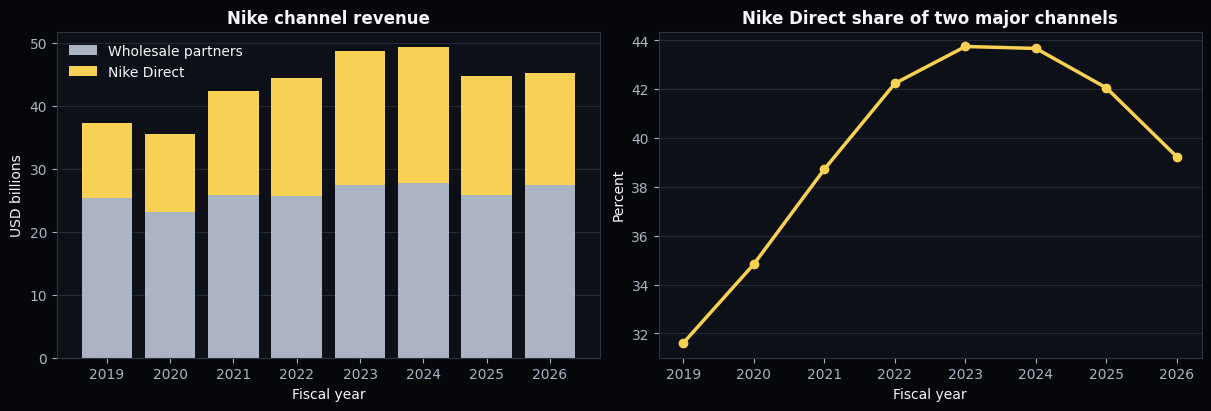

In [137]:
fig_nike, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].bar(nike.fiscal_year, nike.nike_brand_wholesale / 1000,
            label='Wholesale partners', color=CHANNEL_COLORS['Wholesale'])
axes[0].bar(nike.fiscal_year, nike.nike_brand_direct / 1000,
            bottom=nike.nike_brand_wholesale / 1000,
            label='Nike Direct', color=CHANNEL_COLORS['Direct'])
axes[0].set(title='Nike channel revenue', ylabel='USD billions', xlabel='Fiscal year')
axes[0].legend(frameon=False)
axes[1].plot(nike.fiscal_year, nike.direct_share_recalculated,
             marker='o', color=COMPANY_COLORS['Nike'], linewidth=2.5)
axes[1].set(title='Nike Direct share of two major channels',
            ylabel='Percent', xlabel='Fiscal year')
for ax in axes:
    style_axes(ax)
plt.show()


## Part 2: Compare challenger channel growth

Deckers, On and NIKE Brand cannot be compared by subtracting their reported revenue figures.
Deckers and Nike report USD, On reports CHF; their year-ends and scopes differ. Indexing each
company's own wholesale revenue to its FY2021 level preserves within-company growth while
avoiding a fake currency conversion.

## Step 15: Recalculate peer Direct share

**Formula or operation:** Peer Direct share = Direct revenue / total revenue x 100.

**Why?** Recalculation checks the prepared values and provides a comparable channel-mix definition within each peer's reported scope.

> **ASSUMPTION:** Similar formulas do not make company scopes identical. The Deckers series,
> On consolidated results and Nike channel data have different economic scopes.


In [138]:
peers['direct_share_recalculated'] = 100 * peers.direct_revenue / peers.total_revenue
assert np.allclose(peers.direct_share_recalculated, peers.direct_share_pct, atol=.01)
display(peers[['company', 'fiscal_year', 'direct_share_recalculated', 'scope']])

,company,fiscal_year,direct_share_recalculated,scope
0,Deckers,2019,17.070209,Deckers reported channel series
1,Deckers,2020,21.418565,Deckers reported channel series
2,Deckers,2021,29.059064,Deckers reported channel series
3,Deckers,2022,29.488758,Deckers reported channel series
4,Deckers,2023,34.470485,Deckers reported channel series
5,Deckers,2024,37.670833,Deckers reported channel series
6,Deckers,2025,37.406195,Deckers reported channel series
7,Deckers,2026,36.158356,Deckers reported channel series
8,On,2021,38.062379,On consolidated; all products
9,On,2022,36.420915,On consolidated; all products


## Step 16: Build a common wholesale table

**Formula or operation:** Append Nike, Deckers and On wholesale observations without converting currencies.

**Why?** The combined table enables within-company normalization. The raw revenue column must never be summed across currencies.


In [139]:
nike_wholesale = nike[['fiscal_year', 'nike_brand_wholesale']].rename(
    columns={'nike_brand_wholesale': 'wholesale_revenue'})
nike_wholesale['company'] = 'Nike'
nike_wholesale['currency'] = 'USD'
nike_wholesale['scope'] = 'Nike; all products'
wholesale = pd.concat([nike_wholesale, peers[['company', 'fiscal_year',
    'wholesale_revenue', 'currency', 'scope']]], ignore_index=True)
wholesale = wholesale.sort_values(['company', 'fiscal_year']).reset_index(drop=True)
assert not wholesale.duplicated(['company', 'fiscal_year']).any()
display(wholesale.head())


,fiscal_year,wholesale_revenue,company,currency,scope
0,2019,185.057,Deckers,USD,Deckers reported channel series
1,2020,277.097,Deckers,USD,Deckers reported channel series
2,2021,405.243,Deckers,USD,Deckers reported channel series
3,2022,628.674,Deckers,USD,Deckers reported channel series
4,2023,925.877,Deckers,USD,Deckers reported channel series


## Step 17: Define the chart window and the common comparison window

**Formula or operation:** Keep FY2019-FY2024 for the chart, then retain FY2021-FY2024 as a
separate common window for like-period growth calculations.

**Why?** The chart should show the 2019 and 2020 history available for Nike and Deckers. On
does not report observations in this prepared dataset until 2021, so those two years remain
absent rather than being estimated. The common 2021-2024 table keeps the summary statistics
comparable across all three companies.

> **ASSUMPTION:** Fiscal years are labels. Nike ends in May, Deckers in March and On in December.


In [140]:
wholesale_chart = wholesale.loc[wholesale.fiscal_year.between(2019, 2024)].copy()
comparison = wholesale.loc[wholesale.fiscal_year.between(2021, 2024)].copy()

chart_availability = wholesale_chart.groupby('company').fiscal_year.agg(['min', 'max', 'count'])
common_counts = comparison.groupby('company').fiscal_year.nunique()
assert chart_availability.loc['Nike', 'min'] == 2019
assert chart_availability.loc['Deckers', 'min'] == 2019
assert chart_availability.loc['On', 'min'] == 2021
assert common_counts.eq(4).all()
display(chart_availability.rename(columns={'min': 'first_year', 'max': 'last_year',
                                           'count': 'observations'}))


,first_year,last_year,observations
company,,,
Deckers,2019,2024,6
Nike,2019,2024,6
On,2021,2024,4


## Step 18: Index wholesale revenue to each company's first available year

**Formula or operation:** Wholesale index = company wholesale revenue / first available
wholesale revenue x 100. Nike and Deckers use FY2019; On uses FY2021.

**Why?** This adds the requested 2019 and 2020 history without inventing On observations.
Within-company indexing cancels currency units and compares growth paths, not market share.

> **ASSUMPTION:** Mixed base years are clearly disclosed, so the chart is suitable for growth
> direction but not for comparing absolute company size or identical elapsed periods.


In [141]:
first_observation = (wholesale_chart.sort_values('fiscal_year')
                     .groupby('company', as_index=False).first()
                     [['company', 'fiscal_year', 'wholesale_revenue']]
                     .rename(columns={'fiscal_year': 'base_year',
                                      'wholesale_revenue': 'base_wholesale_revenue'}))
wholesale_chart = wholesale_chart.merge(first_observation, on='company', validate='many_to_one')
wholesale_chart['wholesale_index_base'] = (
    100 * wholesale_chart.wholesale_revenue / wholesale_chart.base_wholesale_revenue)
assert np.allclose(wholesale_chart.loc[
    wholesale_chart.fiscal_year.eq(wholesale_chart.base_year), 'wholesale_index_base'], 100)
display(wholesale_chart[['company', 'fiscal_year', 'base_year', 'wholesale_index_base']])


,company,fiscal_year,base_year,wholesale_index_base
0,Deckers,2019,2019,100.000000
1,Deckers,2020,2019,149.736027
2,Deckers,2021,2019,218.982800
3,Deckers,2022,2019,339.719114
4,Deckers,2023,2019,500.319901
5,Deckers,2024,2019,608.529264
6,Nike,2019,2019,100.000000
7,Nike,2020,2019,91.082878
8,Nike,2021,2019,101.868387
9,Nike,2022,2019,100.727688


## Step 19: Calculate cumulative wholesale growth

**Formula or operation:** Cumulative growth = FY2024 wholesale / FY2021 wholesale - 1.

**Why?** This reports total expansion over the common window. It does not say whether growth came from running shoes, new doors, price, units or acquisitions.

In [142]:
wholesale_pivot = comparison.pivot(index='company', columns='fiscal_year',
                                   values='wholesale_revenue')
wholesale_growth = (wholesale_pivot[2024] / wholesale_pivot[2021] - 1).rename(
    'cumulative_growth_2021_2024')
display(wholesale_growth.to_frame())

,cumulative_growth_2021_2024
company,
Deckers,1.778891
Nike,0.071820
On,2.064840


## Step 20: Calculate wholesale CAGR

**Formula or operation:** CAGR = (FY2024 / FY2021)^(1/3) - 1.

**Why?** CAGR expresses the constant annual rate that would produce the same three-year cumulative change. Actual annual growth can be much less smooth.

In [143]:
wholesale_cagr = ((wholesale_pivot[2024] / wholesale_pivot[2021]) ** (1 / 3) - 1).rename(
    'wholesale_cagr_2021_2024')
growth_summary = pd.concat([wholesale_growth, wholesale_cagr], axis=1).reset_index()
display(growth_summary)

,company,cumulative_growth_2021_2024,wholesale_cagr_2021_2024
0,Deckers,1.778891,0.405909
1,Nike,0.071820,0.023389
2,On,2.064840,0.452566


## Step 21: Plot indexed wholesale expansion from 2019

**Formula or operation:** Plot the within-company wholesale index across every available
observation from FY2019 through FY2024 and identify each series with a fixed-size logo label.

**Why?** The longer view shows that Deckers growth was already underway before 2021 while
leaving On's unavailable 2019-2020 values blank. Logos and high-contrast colors make the lines
distinguishable without changing the underlying data.


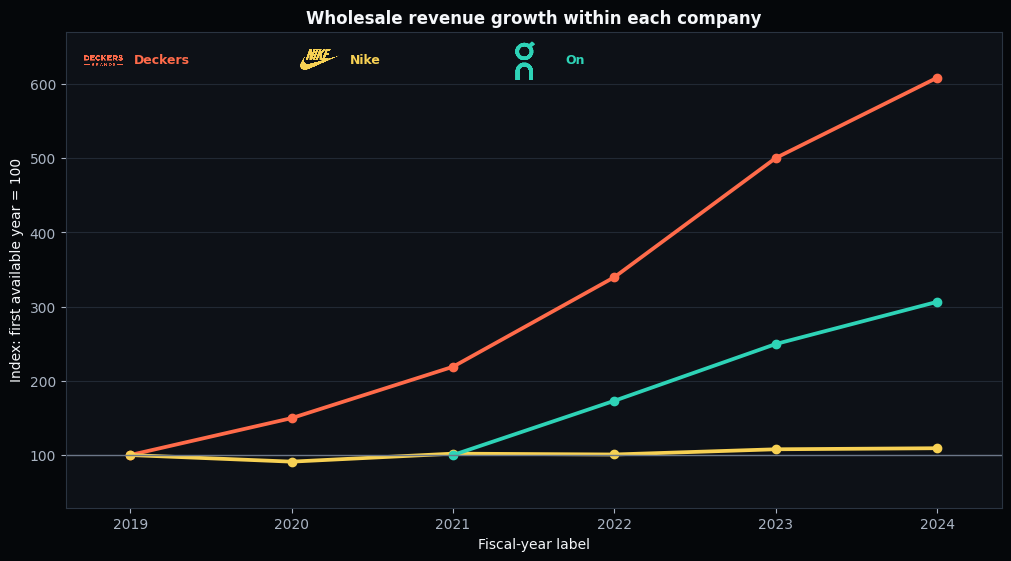

In [144]:
fig_wholesale, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
for company, group in wholesale_chart.groupby('company'):
    group = group.sort_values('fiscal_year')
    ax.plot(group.fiscal_year, group.wholesale_index_base,
            marker='o', linewidth=2.7, color=COMPANY_COLORS[company])
ax.axhline(100, color=REFERENCE, linewidth=1)
ax.set(title='Wholesale revenue growth within each company',
       xlabel='Fiscal-year label', ylabel='Index: first available year = 100')
ax.set_xticks(range(2019, 2025))
ax.margins(x=.08, y=.12)
style_axes(ax)
add_company_labels(ax, ['Deckers', 'Nike', 'On'])
plt.show()


## Step 22: Compare Direct-share trajectories

**Formula or operation:** Plot reported Direct share for Nike, Deckers and On within each scope.

**Why?** The chart tests whether competitors were exclusively wholesale-led. A rising peer
Direct share would show that wholesale growth and Direct investment can coexist.

> **ASSUMPTION:** Direct definitions and company scopes may differ in detail. The chart compares direction, not identical channel economics.


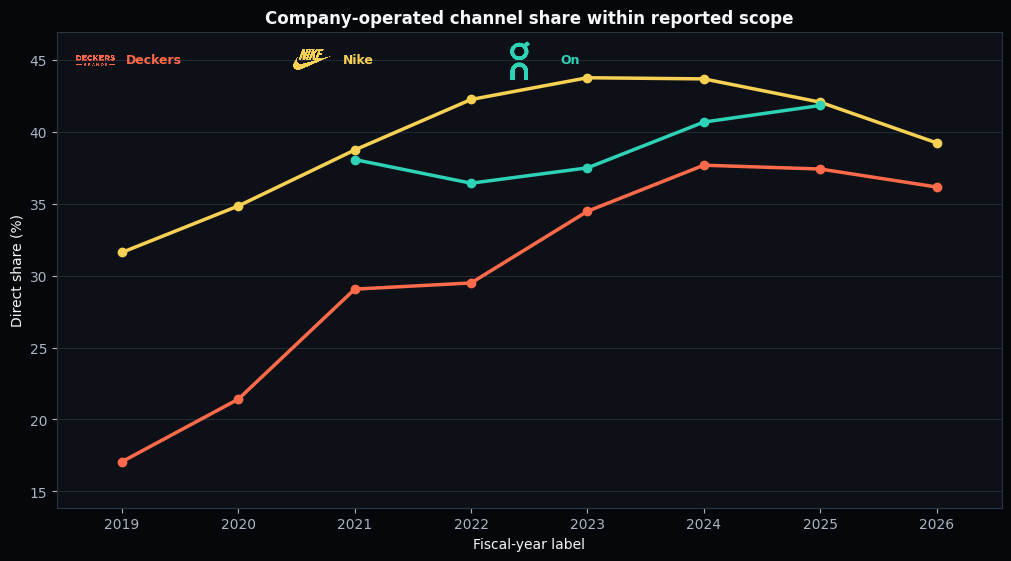

In [145]:
direct_mix = pd.concat([
    nike[['fiscal_year', 'direct_share_recalculated']].assign(company='Nike').rename(
        columns={'direct_share_recalculated': 'direct_share_pct'}),
    peers[['company', 'fiscal_year', 'direct_share_recalculated']].rename(
        columns={'direct_share_recalculated': 'direct_share_pct'})
], ignore_index=True)
fig_direct, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
for company, group in direct_mix.groupby('company'):
    group = group.sort_values('fiscal_year')
    ax.plot(group.fiscal_year, group.direct_share_pct, marker='o',
            linewidth=2.5, color=COMPANY_COLORS[company])
ax.set(title='Company-operated channel share within reported scope',
       xlabel='Fiscal-year label', ylabel='Direct share (%)')
ax.margins(x=.08, y=.12)
style_axes(ax)
add_company_labels(ax, ['Deckers', 'Nike', 'On'])
plt.show()


## Part 2B: Compare equity-price paths and event timing

Stock prices aggregate changing expectations about growth, margins, risk, interest rates and the
broader market. They can show when investors repriced each company, but they cannot isolate the
effect of distribution strategy by themselves.

## Step 22A: Normalize adjusted stock prices

**Formula:** `Price index = adjusted close / first available adjusted close x 100`.

**Why?** Nike, Deckers and On trade at different dollar prices. Indexing each stock to 100 makes
their percentage paths comparable while preserving the actual daily observations.

> **ASSUMPTION:** Nike and Deckers use January 2, 2019 as their base. On uses its first available
> observation on September 15, 2021. The different base dates mean the chart compares paths, not
> equal holding-period returns. Yahoo adjusted close is used to account for reported splits and
> distributions.

In [146]:
prices = prices.sort_values(['company', 'date']).copy()
prices['base_date'] = prices.groupby('company').date.transform('first')
prices['base_adj_close'] = prices.groupby('company').adj_close.transform('first')
prices['price_index'] = 100 * prices.adj_close / prices.base_adj_close
price_index = prices[['date', 'company', 'ticker', 'adj_close', 'base_date',
                      'base_adj_close', 'price_index', 'source_url']].copy()
assert np.allclose(price_index.groupby('company').price_index.first(), 100)
display(price_index.groupby('company').agg(
    first_date=('date', 'min'), last_date=('date', 'max'), observations=('date', 'size')))


,first_date,last_date,observations
company,,,
Deckers,2019-01-02,2026-09-15,1936
Nike,2019-01-02,2026-09-15,1936
On,2021-09-15,2026-09-15,1255


## Step 22B: Build the event ledger

**Formula or operation:** Record a small set of dated strategy, retailer, leadership and macro
events, with one primary source URL for each marker.

**Why?** Event markers make the timeline readable without claiming an event caused the nearby
price move. The selected events are directly relevant to the distribution thesis or footwear
input-cost risk:

- [Nike Consumer Direct Acceleration operating-model update](https://investors.nike.com/investors/news-events-and-reports/investor-news/investor-news-details/2020/Nike-Announces-Senior-Leadership-Changes-to-Unlock-Future-Growth-Through-the-Consumer-Direct-Acceleration/default.aspx)
- [Foot Locker vendor-mix and diversification update](https://investors.footlocker-inc.com/news-releases/news-release-details/foot-locker-inc-reports-2021-fourth-quarter-and-full-year)
- [Nike announcement of Elliott Hill as CEO](https://about.nike.com/en/newsroom/releases/nike-inc-announces-return-of-long-time-nike-veteran-elliott-hill-as-president-and-ceo)
- [White House April 2, 2025 reciprocal-tariff announcement](https://www.whitehouse.gov/fact-sheets/2025/04/fact-sheet-president-donald-j-trump-declares-national-emergency-to-increase-our-competitive-edge-protect-our-sovereignty-and-strengthen-our-national-and-economic-security/)

> **ASSUMPTION:** These are contextual milestones selected for this case study, not a complete
> event study. No market-model adjustment, statistical significance test or causal attribution is
> performed.

In [147]:
events = pd.DataFrame([
    {'event_date': '2020-07-22', 'event': 'CDA operating-model update',
     'category': 'strategy',
     'source_url': 'https://investors.nike.com/investors/news-events-and-reports/investor-news/investor-news-details/2020/Nike-Announces-Senior-Leadership-Changes-to-Unlock-Future-Growth-Through-the-Consumer-Direct-Acceleration/default.aspx'},
    {'event_date': '2022-02-25', 'event': 'Foot Locker vendor-mix reset',
     'category': 'retailer',
     'source_url': 'https://investors.footlocker-inc.com/news-releases/news-release-details/foot-locker-inc-reports-2021-fourth-quarter-and-full-year'},
    {'event_date': '2024-09-19', 'event': 'Elliott Hill announced as CEO',
     'category': 'leadership',
     'source_url': 'https://about.nike.com/en/newsroom/releases/nike-inc-announces-return-of-long-time-nike-veteran-elliott-hill-as-president-and-ceo'},
    {'event_date': '2025-04-02', 'event': 'Liberation Day tariffs announced',
     'category': 'macro',
     'source_url': 'https://www.whitehouse.gov/fact-sheets/2025/04/fact-sheet-president-donald-j-trump-declares-national-emergency-to-increase-our-competitive-edge-protect-our-sovereignty-and-strengthen-our-national-and-economic-security/'},
])
events['event_date'] = pd.to_datetime(events.event_date)
assert events.event_date.between(research_start, research_cutoff).all()
assert events.source_url.str.startswith('https://').all()
display(events)


,event_date,event,category,source_url
0,2020-07-22,CDA operating-model update,strategy,https://investors.nike.com/investors/news-even...
1,2022-02-25,Foot Locker vendor-mix reset,retailer,https://investors.footlocker-inc.com/news-rele...
2,2024-09-19,Elliott Hill announced as CEO,leadership,https://about.nike.com/en/newsroom/releases/ni...
3,2025-04-02,Liberation Day tariffs announced,macro,https://www.whitehouse.gov/fact-sheets/2025/04...


## Step 22C: Plot indexed prices with event markers

**Formula or operation:** Draw each daily price index and add a vertical line on every event date.
Company logos appear only inside the fixed-size series labels.

**Why?** This combines market expectations and the strategic timeline in one view. Read changes
around an event as a prompt for further research, not as an event-return estimate.

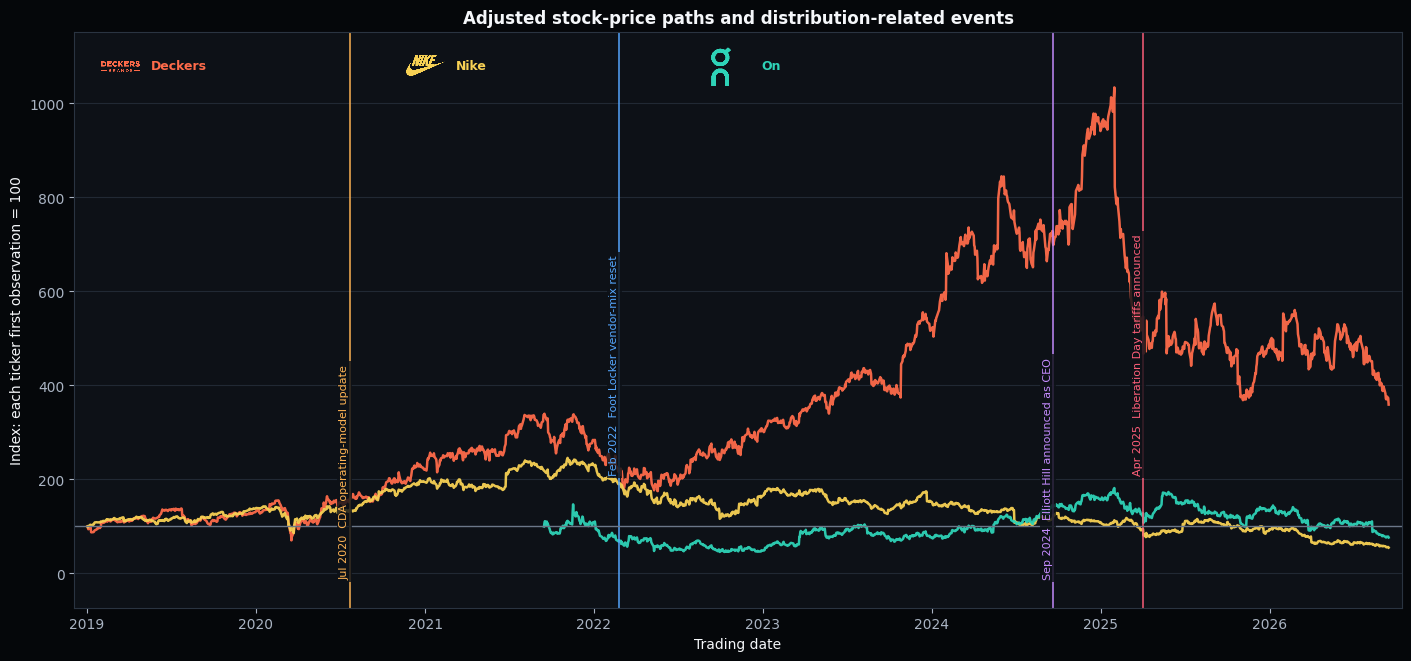

In [148]:
fig_price_events, ax = plt.subplots(figsize=(14, 6.5), layout='constrained')
for company, group in price_index.groupby('company'):
    ax.plot(group.date, group.price_index, color=COMPANY_COLORS[company],
            linewidth=1.8, alpha=.95)

for level, event in enumerate(events.itertuples()):
    color = EVENT_COLORS[event.category]
    ax.axvline(event.event_date, color=color, linewidth=1.2, alpha=.9)
    ax.text(event.event_date, .05 + .18 * (level % 2),
            f'{event.event_date:%b %Y}  {event.event}',
            transform=ax.get_xaxis_transform(), rotation=90,
            color=color, fontsize=8, va='bottom', ha='right',
            bbox={'facecolor': PANEL_BACKGROUND, 'edgecolor': 'none', 'alpha': .82, 'pad': 2})

ax.axhline(100, color=REFERENCE, linewidth=1)
ax.set(title='Adjusted stock-price paths and distribution-related events',
       xlabel='Trading date', ylabel='Index: each ticker first observation = 100')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.margins(x=.01, y=.12)
style_axes(ax)
add_company_labels(ax, ['Deckers', 'Nike', 'On'])
plt.show()


## Part 3: Use Foot Locker as retailer-side evidence

Foot Locker reports the percentage of merchandise purchases sourced from Nike. This is useful
because it observes the retailer's vendor concentration. It does not identify running shoes,
mid-tier doors, regional specialty shops, or consumer sell-through.

## Step 23: Validate the Foot Locker percentage

**Formula or operation:** Require vendor concentration between 0% and 100%.

**Why?** The metric is already reported as a percentage, so it should not be divided by revenue or converted into Nike sales.

In [149]:
share_col = 'nike_share_of_foot_locker_purchases_pct'
assert foot_locker[share_col].between(0, 100).all()
display(foot_locker[['purchase_year', share_col, 'metric']])

,purchase_year,nike_share_of_foot_locker_purchases_pct,metric
0,2019,71,Share of all merchandise purchases from Nike
1,2020,75,Share of all merchandise purchases from Nike
2,2021,68,Share of all merchandise purchases from Nike
3,2022,65,Share of all merchandise purchases from Nike
4,2023,65,Share of all merchandise purchases from Nike
5,2024,59,Share of all merchandise purchases from Nike


## Step 24: Calculate annual concentration changes

**Formula or operation:** Annual change in percentage points = current Nike purchase share - prior share.

**Why?** This shows when Foot Locker's dependence on Nike increased or decreased. It does not reveal which party initiated the change.

In [150]:
foot_locker['annual_change_pp'] = foot_locker[share_col].diff()
display(foot_locker[['purchase_year', share_col, 'annual_change_pp']])

,purchase_year,nike_share_of_foot_locker_purchases_pct,annual_change_pp
0,2019,71,NaN
1,2020,75,4.0
2,2021,68,-7.0
3,2022,65,-3.0
4,2023,65,0.0
5,2024,59,-6.0


## Step 25: Measure endpoint and peak declines

**Formula or operation:** Endpoint change = 2024 share - 2019 share; peak decline = 2024 share - maximum share.

**Why?** The endpoint describes the whole observed period; the peak comparison captures the larger decline from the highest concentration year.

In [151]:
fl_indexed = foot_locker.set_index('purchase_year')[share_col]
fl_summary = pd.Series({
    '2019_to_2024_change_pp': fl_indexed.loc[2024] - fl_indexed.loc[2019],
    'peak_share_pct': fl_indexed.max(),
    'peak_year': int(fl_indexed.idxmax()),
    'peak_to_2024_change_pp': fl_indexed.loc[2024] - fl_indexed.max(),
})
display(fl_summary)

2019_to_2024_change_pp     -12
peak_share_pct              75
peak_year                 2020
peak_to_2024_change_pp     -16
dtype: int64

## Step 26: Plot retailer concentration

**Formula or operation:** Plot Foot Locker's annual share of purchases from Nike.

**Why?** The retailer-side series visualizes diversification. Keep the y-axis broad enough that percentage-point changes are not visually exaggerated.

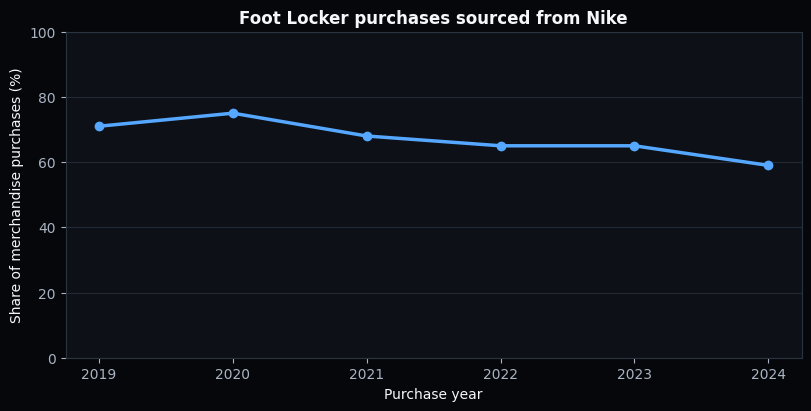

In [152]:
fig_fl, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(foot_locker.purchase_year, foot_locker[share_col], marker='o',
        linewidth=2.5, color=FOOT_LOCKER)
ax.set(title='Foot Locker purchases sourced from Nike',
       xlabel='Purchase year', ylabel='Share of merchandise purchases (%)', ylim=(0, 100))
style_axes(ax)
plt.show()


## Step 27: Align Nike mix with Foot Locker concentration

**Formula or operation:** Inner join on year for 2019-2024.

**Why?** Alignment permits descriptive comparison over shared labels. Nike fiscal years end in May and Foot Locker years end around January/February, so the timing is approximate.

> **ASSUMPTION:** The same year label is treated as comparable even though fiscal year-ends differ. No lead or lag is asserted.

In [153]:
aligned = nike[['fiscal_year', 'direct_share_recalculated']].merge(
    foot_locker[['purchase_year', share_col]],
    left_on='fiscal_year', right_on='purchase_year', validate='one_to_one')
assert len(aligned) == 6
display(aligned)

,fiscal_year,direct_share_recalculated,purchase_year,nike_share_of_foot_locker_purchases_pct
0,2019,31.614482,2019,71
1,2020,34.841578,2020,75
2,2021,38.729062,2021,68
3,2022,42.238463,2022,65
4,2023,43.749102,2023,65
5,2024,43.669460,2024,59


## Step 28: Calculate the descriptive retailer correlation

**Formula or operation:** Correlation = co-movement between Nike Direct share and Foot Locker Nike concentration.

**Why?** A negative value would be consistent with the proposed mechanism, but six annual observations cannot separate strategy from time trends or other causes.

> **ASSUMPTION:** This is descriptive and should not be presented as statistical or causal proof.

In [154]:
retailer_correlation = aligned.direct_share_recalculated.corr(aligned[share_col])
display(pd.Series({'observations': len(aligned),
                  'direct_mix_foot_locker_correlation': retailer_correlation}))

observations                          6.000000
direct_mix_foot_locker_correlation   -0.837771
dtype: float64

## Step 29: Plot the aligned retailer evidence

**Formula or operation:** Plot Nike Direct share and Foot Locker Nike concentration in adjacent panels.

**Why?** Shared years make the timing visible without combining two different percentage definitions on one axis.

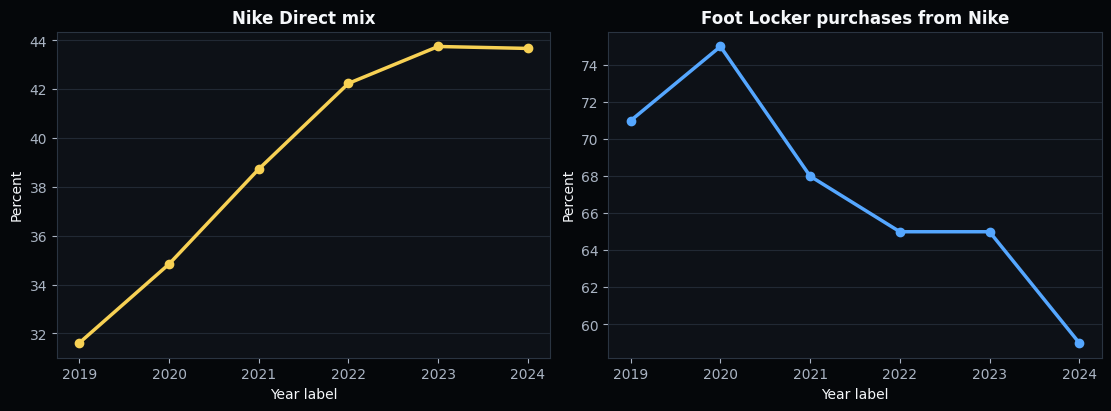

In [155]:
fig_alignment, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].plot(aligned.fiscal_year, aligned.direct_share_recalculated,
             marker='o', color=COMPANY_COLORS['Nike'], linewidth=2.5)
axes[0].set(title='Nike Direct mix', ylabel='Percent', xlabel='Year label')
axes[1].plot(aligned.purchase_year, aligned[share_col],
             marker='o', color=FOOT_LOCKER, linewidth=2.5)
axes[1].set(title='Foot Locker purchases from Nike', ylabel='Percent', xlabel='Year label')
for ax in axes:
    style_axes(ax)
plt.show()


## Part 4: Test claims against what the data actually measure

The evidence supports statements about reported company channels and one retailer's supplier
concentration. It does not directly observe Nike's running-shoe shelf space, store-level
assortments, units sold, customer demand, or global category share.

## Step 30: Build an evidence-claim matrix

**Formula or operation:** Map each claim to the closest available measure and its gap.

**Why?** The matrix prevents a broad narrative from outrunning the evidence. A claim is strongest when its variable, population and timing match the data.

In [156]:
claim_matrix = pd.DataFrame([
    {'claim': 'Nike shifted toward company-operated channels',
     'available_measure': 'Nike Direct share',
     'support_level': 'directly measured',
     'remaining_gap': 'Direct combines owned stores and digital'},
    {'claim': 'Foot Locker reduced dependence on Nike',
     'available_measure': 'Nike share of Foot Locker merchandise purchases',
     'support_level': 'directly measured at one retailer',
     'remaining_gap': 'Not running-specific and not consumer sell-through'},
    {'claim': 'Deckers and On expanded wholesale faster',
     'available_measure': 'Indexed reported wholesale revenue',
     'support_level': 'directly measured within company scope',
     'remaining_gap': 'Different fiscal calendars, scopes, currencies and price/unit mix'},
    {'claim': 'Nike caused competitor growth',
     'available_measure': 'Coincident annual company and retailer trends',
     'support_level': 'not identified',
     'remaining_gap': 'No treated/control store panel or account-change dates'},
    {'claim': 'Nike lost global running market share',
     'available_measure': 'No consistent independent share series in these files',
     'support_level': 'not measured',
     'remaining_gap': 'Need category units/value by brand and geography'},
])
display(claim_matrix)


,claim,available_measure,support_level,remaining_gap
0,Nike shifted toward company-operated channels,Nike Direct share,directly measured,Direct combines owned stores and digital
1,Foot Locker reduced dependence on Nike,Nike share of Foot Locker merchandise purchases,directly measured at one retailer,Not running-specific and not consumer sell-thr...
2,Deckers and On expanded wholesale faster,Indexed reported wholesale revenue,directly measured within company scope,"Different fiscal calendars, scopes, currencies..."
3,Nike caused competitor growth,Coincident annual company and retailer trends,not identified,No treated/control store panel or account-chan...
4,Nike lost global running market share,No consistent independent share series in thes...,not measured,Need category units/value by brand and geography


## Step 31: List plausible alternative explanations

**Formula or operation:** Record mechanisms that can generate the same observed patterns.

**Why?** Causal analysis requires asking what else changed at the same time. This is part of the model, not a footnote added after seeing the result.

In [157]:
alternatives = pd.DataFrame({'alternative_explanation': [
    'Deckers and On product innovation and brand demand',
    'Overall performance-running category growth',
    'COVID store closures and channel migration',
    'Supply-chain availability and inventory differences',
    "Foot Locker's own assortment and diversification strategy",
    'Pricing, currency and product-mix changes in reported revenue',
    'Different geographic expansion and store footprints',
]})
display(alternatives)


,alternative_explanation
0,Deckers and On product innovation and brand de...
1,Overall performance-running category growth
2,COVID store closures and channel migration
3,Supply-chain availability and inventory differ...
4,Foot Locker's own assortment and diversificati...
5,"Pricing, currency and product-mix changes in r..."
6,Different geographic expansion and store footp...


## Step 32: Define the missing causal dataset

**Formula or operation:** One row per store-brand-month with treatment, exposure and outcome fields.

**Why?** A credible test needs store-level timing and outcomes. The schema below documents required real data; it does not fabricate observations.

> **ASSUMPTION:** The required retailer panel is unavailable. No causal coefficient is estimated in this notebook.

In [158]:
required_causal_columns = [
    'month', 'store_id', 'geography', 'store_type', 'brand',
    'retail_sales_value', 'units_sold', 'average_selling_price',
    'sku_count', 'on_shelf_availability', 'inventory_units',
    'nike_account_change_date', 'nike_allocation_change',
    'store_closed', 'new_product_launch', 'local_category_sales',
]
causal_panel_path = root / 'data/raw/retailer_running_panel.parquet'
causal_panel_available = causal_panel_path.exists()
display(pd.Series({'causal_panel_available': causal_panel_available,
                  'required_columns': ', '.join(required_causal_columns)}))

causal_panel_available                                                False
required_columns          month, store_id, geography, store_type, brand,...
dtype: object

## Step 33: State the difference-in-differences formula

**Formula or operation:** Effect = (after - before at affected stores) - (after - before at comparable unaffected stores).

**Why?** Subtracting the control change removes common category trends, but only if treated and control stores would otherwise have followed parallel paths.

> **ASSUMPTION:** Account changes are not random. Even a difference-in-differences design may remain biased if Nike selected accounts based on expected performance.

In [159]:
did_design = pd.DataFrame([
    {'component': 'Treatment', 'definition': 'Nike account exit or documented assortment/allocation reduction'},
    {'component': 'Outcome', 'definition': 'Nike share of running-footwear units or retail sales'},
    {'component': 'Controls', 'definition': 'Comparable continuously supplied stores'},
    {'component': 'Required check', 'definition': 'Parallel pre-treatment trends'},
    {'component': 'Key controls', 'definition': 'Closures, category demand, price, launches, inventory, geography'},
])
display(did_design)

,component,definition
0,Treatment,Nike account exit or documented assortment/all...
1,Outcome,Nike share of running-footwear units or retail...
2,Controls,Comparable continuously supplied stores
3,Required check,Parallel pre-treatment trends
4,Key controls,"Closures, category demand, price, launches, in..."


## Part 5: Build a monitoring scorecard

A case study should finish with evidence that could update the investment thesis. The scorecard
below separates currently available annual indicators from data still required. It does not
assign arbitrary points or turn incomplete evidence into a single score.

## Step 34: Calculate the latest observed annual changes

**Formula or operation:** Latest change = latest value - prior-year value, or latest / prior - 1 for revenue.

**Why?** The latest annual direction helps monitor whether wholesale and Direct are recovering, but it is not a forward forecast.

In [160]:
nike_latest = nike.sort_values('fiscal_year').tail(2)
latest_changes = pd.Series({
    'nike_wholesale_growth_latest': nike_latest.nike_brand_wholesale.iloc[-1] /
                                    nike_latest.nike_brand_wholesale.iloc[-2] - 1,
    'nike_direct_growth_latest': nike_latest.nike_brand_direct.iloc[-1] /
                                nike_latest.nike_brand_direct.iloc[-2] - 1,
    'nike_direct_share_change_latest_pp': nike_latest.direct_share_recalculated.iloc[-1] -
                                          nike_latest.direct_share_recalculated.iloc[-2],
    'nike_gross_margin_change_latest_pp': nike_latest.nike_inc_gross_margin_pct.iloc[-1] -
                                          nike_latest.nike_inc_gross_margin_pct.iloc[-2],
    'foot_locker_nike_share_change_latest_pp': foot_locker[share_col].iloc[-1] -
                                               foot_locker[share_col].iloc[-2],
})
display(latest_changes)

nike_wholesale_growth_latest               0.060658
nike_direct_growth_latest                 -0.056594
nike_direct_share_change_latest_pp        -2.825148
nike_gross_margin_change_latest_pp         0.200000
foot_locker_nike_share_change_latest_pp   -6.000000
dtype: float64

## Step 35: Create the research scorecard

**Formula or operation:** Pair each thesis question with its current metric, source and interpretation rule.

**Why?** A scorecard makes future updates consistent. It identifies which evidence should change a revenue assumption, a margin assumption, or only confidence in the narrative.

> **ASSUMPTION:** No composite score or pass/fail threshold is assigned. Thresholds should be defined only after obtaining consistent quarterly sell-through and profitability data.

In [161]:
scorecard = pd.DataFrame([
    {'question': 'Is partner distribution recovering?',
     'current_metric': 'NIKE Brand wholesale growth',
     'latest_value': latest_changes.nike_wholesale_growth_latest,
     'what_improves_confidence': 'Sustained growth plus independent sell-through and productive doors'},
    {'question': 'Is Nike reducing excessive Direct dependence?',
     'current_metric': 'Annual Direct-share change',
     'latest_value': latest_changes.nike_direct_share_change_latest_pp / 100,
     'what_improves_confidence': 'Balanced channel growth without collapsing digital productivity'},
    {'question': 'Are channel changes profitable?',
     'current_metric': 'Nike Inc. gross-margin change',
     'latest_value': latest_changes.nike_gross_margin_change_latest_pp / 100,
     'what_improves_confidence': 'Full-price sell-through and margin recovery excluding one-offs'},
    {'question': 'Is retailer dependence stabilizing?',
     'current_metric': 'Foot Locker Nike purchase-share change',
     'latest_value': latest_changes.foot_locker_nike_share_change_latest_pp / 100,
     'what_improves_confidence': 'Stable orders plus consumer sell-through by category'},
    {'question': 'Is running share recovering?',
     'current_metric': 'Unavailable independent consistent series',
     'latest_value': np.nan,
     'what_improves_confidence': 'Independent brand share by units/value, doors and geography'},
])
display(scorecard)

,question,current_metric,latest_value,what_improves_confidence
0,Is partner distribution recovering?,NIKE Brand wholesale growth,0.060658,Sustained growth plus independent sell-through...
1,Is Nike reducing excessive Direct dependence?,Annual Direct-share change,-0.028251,Balanced channel growth without collapsing dig...
2,Are channel changes profitable?,Nike Inc. gross-margin change,0.002000,Full-price sell-through and margin recovery ex...
3,Is retailer dependence stabilizing?,Foot Locker Nike purchase-share change,-0.060000,Stable orders plus consumer sell-through by ca...
4,Is running share recovering?,Unavailable independent consistent series,NaN,"Independent brand share by units/value, doors ..."


## Step 36: Build the case-study dashboard

**Formula or operation:** Combine Nike channels, normalized wholesale growth, Direct mix and Foot Locker concentration.

**Why?** The four panels triangulate the hypothesis while keeping distinct metrics on distinct axes.

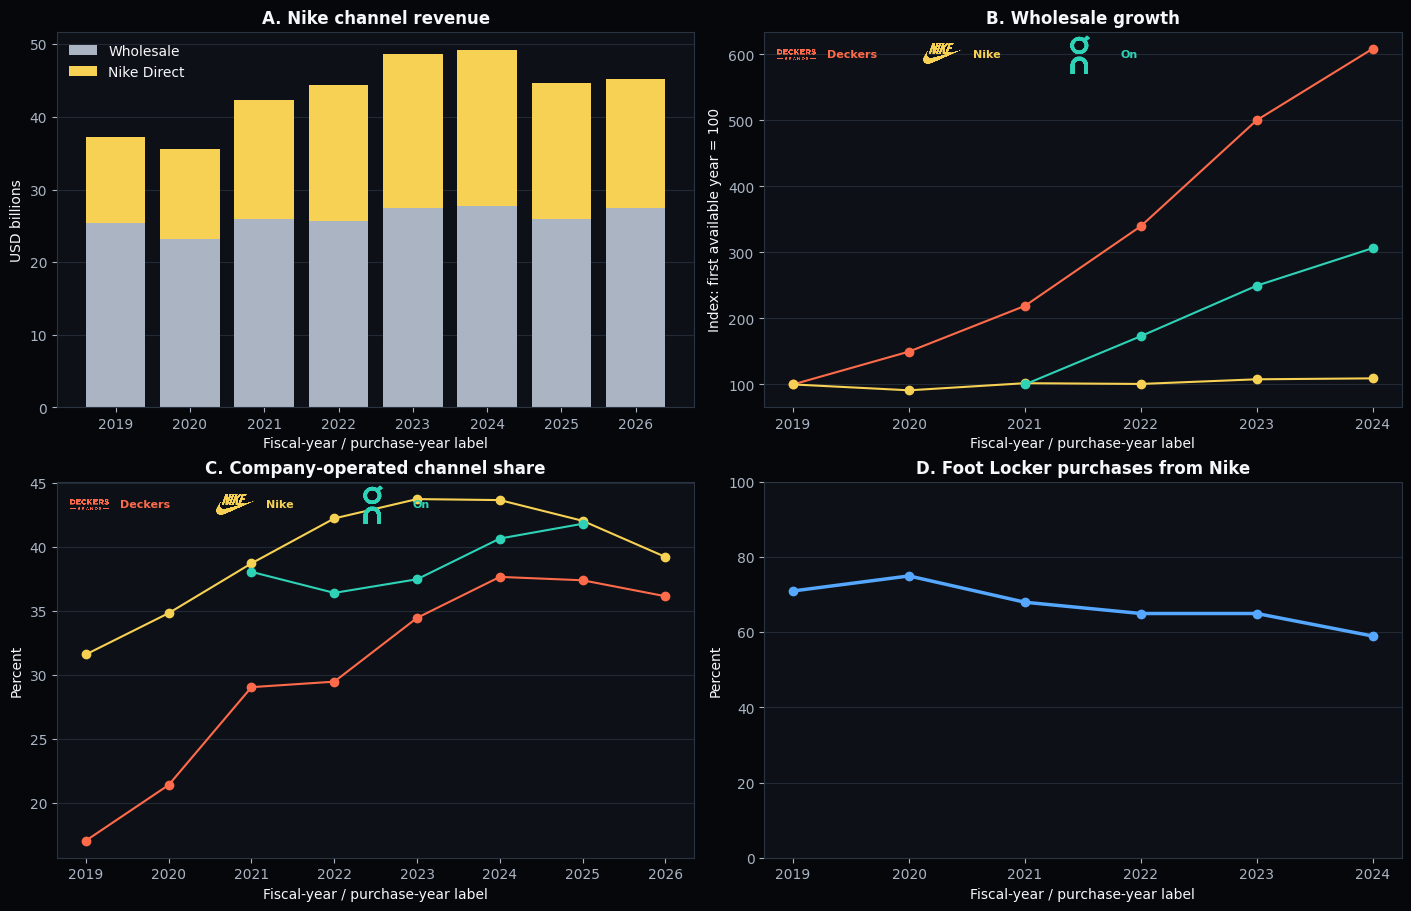

In [162]:
fig_dashboard, axes = plt.subplots(2, 2, figsize=(14, 9), layout='constrained')
axes[0, 0].bar(nike.fiscal_year, nike.nike_brand_wholesale / 1000,
               label='Wholesale', color=CHANNEL_COLORS['Wholesale'])
axes[0, 0].bar(nike.fiscal_year, nike.nike_brand_direct / 1000,
               bottom=nike.nike_brand_wholesale / 1000,
               label='Nike Direct', color=CHANNEL_COLORS['Direct'])
axes[0, 0].set(title='A. Nike channel revenue', ylabel='USD billions')
axes[0, 0].legend(frameon=False)

for company, group in wholesale_chart.groupby('company'):
    group = group.sort_values('fiscal_year')
    axes[0, 1].plot(group.fiscal_year, group.wholesale_index_base,
                    marker='o', color=COMPANY_COLORS[company])
axes[0, 1].set(title='B. Wholesale growth',
               ylabel='Index: first available year = 100')
axes[0, 1].set_xticks(range(2019, 2025))
add_company_labels(axes[0, 1], ['Deckers', 'Nike', 'On'], fontsize=8)

for company, group in direct_mix.groupby('company'):
    group = group.sort_values('fiscal_year')
    axes[1, 0].plot(group.fiscal_year, group.direct_share_pct,
                    marker='o', color=COMPANY_COLORS[company])
axes[1, 0].set(title='C. Company-operated channel share', ylabel='Percent')
add_company_labels(axes[1, 0], ['Deckers', 'Nike', 'On'], fontsize=8)

axes[1, 1].plot(foot_locker.purchase_year, foot_locker[share_col],
                marker='o', color=FOOT_LOCKER, linewidth=2.5)
axes[1, 1].set(title='D. Foot Locker purchases from Nike', ylabel='Percent', ylim=(0, 100))

for ax in axes.flat:
    ax.set_xlabel('Fiscal-year / purchase-year label')
    style_axes(ax)
plt.show()


## Step 37: Save the auditable case-study outputs

**Formula or operation:** Save calculated tables, figures and a run manifest.

**Why?** Separate outputs make it clear which values were reported, which were calculated, and which questions remain unresolved.

In [163]:
output.mkdir(parents=True, exist_ok=True)
tables = {
    'nike_channel_analysis': nike,
    'peer_channel_analysis': peers,
    'wholesale_chart_2019_2024': wholesale_chart,
    'wholesale_comparison': comparison,
    'wholesale_growth_summary': growth_summary,
    'foot_locker_analysis': foot_locker,
    'aligned_retailer_evidence': aligned,
    'nike_endpoint_changes': nike_endpoints,
    'claim_matrix': claim_matrix,
    'alternative_explanations': alternatives,
    'research_scorecard': scorecard,
    'equity_price_index': price_index,
    'event_ledger': events,
}
for name, table in tables.items():
    table.to_csv(output / f'{name}.csv', index=False)
for name, figure in [('nike_channels', fig_nike), ('wholesale_index', fig_wholesale),
                     ('direct_mix', fig_direct), ('foot_locker', fig_fl),
                     ('aligned_retailer', fig_alignment),
                     ('equity_prices_with_events', fig_price_events),
                     ('dashboard', fig_dashboard)]:
    figure.savefig(output / f'{name}.png', dpi=160, bbox_inches='tight',
                   facecolor=BACKGROUND)
manifest = {'notebook': 'research/nike_distribution_case_study.ipynb',
            'preprocessing_manifest': 'data/preprocess/preprocessing_manifest.csv',
            'research_cutoff': research_cutoff.date().isoformat(),
            'generated_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'causal_estimate_produced': False, 'tables': list(tables)}
(output / 'manifest.json').write_text(json.dumps(manifest, indent=2))
display(pd.Series({'results_directory': str(output)}))


results_directory    /Users/isha/Desktop/Projects/Equity-Research-R...
dtype: object

## Interpretation after running the notebook

Read the result in layers. First describe Nike's Direct share and absolute wholesale dollars.
Then compare each company's wholesale growth with itself. Use Foot Locker as retailer-side
triangulation, while keeping its metric and population precise. Finally, compare every claim
with the claim matrix and alternative explanations.

A defensible conclusion can say that the channel shifts and rival growth occurred together,
that Foot Locker's vendor concentration changed, and that the mechanism is commercially
plausible. It should not convert indexed revenue into global running market share or present
the annual correlations as causal evidence.

The next material upgrade is a retailer-level running-footwear panel with account-change dates,
units, sales, prices, assortments, availability and comparable continuously supplied stores.
Until that exists, use this case study to inform the strength and risk of the operating thesis,
while changing DCF assumptions only when verified evidence supports sales, margin or reinvestment.